<a href="https://colab.research.google.com/github/NaveenHerath/llm-from-scratch/blob/main/day05_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent and Backprop

what we can do to minimize the loss?
Gradient descent & backprop


In [1]:
#imports
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

In [7]:
#get the data, tokenize & get the batch
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)                        # 65
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

block_size = 8     # T: characters per chunk
batch_size = 32    # B: chunks per batch (was 4 on Day 4)-32 chunks in the 1

def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

#here the batch size is 32, which means instead of 4 batches here we get 32 chunks of texts in to a single batch
xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print('targets:')
print(yb.shape)
#a batch contains 32 chunks, with 8 characters each


inputs:
torch.Size([32, 8])
targets:
torch.Size([32, 8])


In [8]:
#build the model
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)      # (B, T, C)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)              # (B*T, C)
            targets = targets.view(B*T)               # (B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self(idx)                  # (B, T, C)
            logits = logits[:, -1, :]                 # (B, C)
            probs = F.softmax(logits, dim=-1)         # (B, C)
            idx_next = torch.multinomial(probs, num_samples=1)   # (B, 1)
            idx = torch.cat((idx, idx_next), dim=1)   # (B, T+1)
        return idx

In [9]:
#create the model and the optimizer
torch.manual_seed(1337)
model = BigramLanguageModel(vocab_size)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [10]:
#the trainng loop
losses = []

for step in range(10000):
    xb, yb = get_batch('train')        # 1. get a batch
    logits, loss = model(xb, yb)       # 2. forward pass: compute the loss
    optimizer.zero_grad()              # 3. clear the old gradients
    loss.backward()                    # 4. backward pass: compute new gradients
    optimizer.step()                   # 5. nudge every weight
    losses.append(loss.item())

    if step % 1000 == 0:
        print(step, round(loss.item(), 4))

print('last 100 steps, average:', round(sum(losses[-100:]) / 100, 4))

0 4.6485
1000 3.7027
2000 3.1231
3000 2.7293
4000 2.5701
5000 2.4917
6000 2.4764
7000 2.4187
8000 2.4358
9000 2.4548
last 100 steps, average: 2.4685


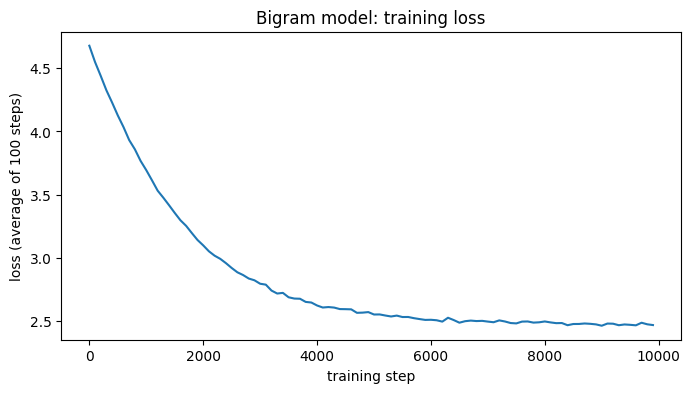

In [11]:
#ploting the loss curve
avg = torch.tensor(losses).view(-1, 100).mean(dim=1)

plt.figure(figsize=(8, 4))
plt.plot(range(0, 10000, 100), avg)
plt.xlabel('training step')
plt.ylabel('loss (average of 100 steps)')
plt.title('Bigram model: training loss')
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
#generate 500 characters from the trained model
start = torch.zeros((1, 1), dtype=torch.long)
out = model.generate(start, max_new_tokens=500)
print(decode(out[0].tolist()))


LA c wo the;
Pancalolinghowhatharean:
QA:

Wwhass bowoond;
Fomere d shdeenotep.
CI y mbotot swefesealso br. ave aviasurf my, yxMPZI ivee iuedrd whar ksth y h bora s be hese, woweee; the! KI 'de, ulseecherd d o blllando;LUCEO, oraingofof win!
RIfans picspeserer hee anf,
TOFonk? me ain ckntoty dedo bo'llll st ta d:
ELIS me hurf lal y, ma dus pe athouo
BEY:! Indy; by s afreanoo adicererupa anse tecorro llaus a!
OLengerithesinthengove fal amas trr
TI ar I t, mes, o sar; my w, fredeeyove
THek' merer,


Experiments

In [14]:
#reusable training function
def train(lr, steps, clear_gradients=True):
    torch.manual_seed(1337)
    m = BigramLanguageModel(vocab_size)
    opt = torch.optim.AdamW(m.parameters(), lr=lr)
    history = []
    for step in range(steps):
        xb, yb = get_batch('train')
        logits, loss = m(xb, yb)
        if clear_gradients:
            opt.zero_grad()
        loss.backward()
        opt.step()
        history.append(loss.item())
    return m, history

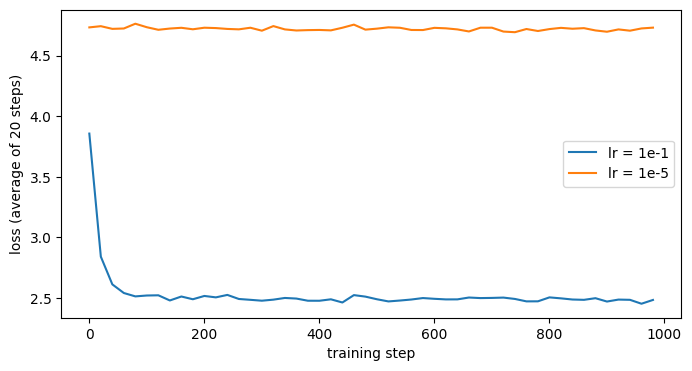

lr 1e-1: 3.8562 -> 2.4839
lr 1e-5: 4.7321 -> 4.73


In [17]:
#run it with 1e-1 and 1e-5 / change the learning rate and see the rate of learning
_, high = train(lr=1e-1, steps=1000)
_, low = train(lr=1e-5, steps=1000)

smooth = lambda h: torch.tensor(h).view(-1, 20).mean(dim=1)

plt.figure(figsize=(8, 4))
plt.plot(range(0, 1000, 20), smooth(high), label='lr = 1e-1')
plt.plot(range(0, 1000, 20), smooth(low), label='lr = 1e-5')
plt.xlabel('training step')
plt.ylabel('loss (average of 20 steps)')
plt.legend()
plt.savefig('lr_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

print('lr 1e-1:', round(sum(high[:20]) / 20, 4), '->', round(sum(high[-20:]) / 20, 4))
print('lr 1e-5:', round(sum(low[:20]) / 20, 4), '->', round(sum(low[-20:]) / 20, 4))